#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




# Introduction:
Amazon Alexa Customer Review Sentiment Analysis
Objective: Classify reviews as positive or negative using Random Forest

In [1]:
# Necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the dataset

file_path = '/content/drive/MyDrive/amazon_alexa.tsv'

df = pd.read_csv(file_path, sep='\t')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


Data Check and clean Up

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB
None


In [6]:
# Check for missing values
print(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [7]:
# Check feedback distribution
print(df['feedback'].value_counts())

feedback
1    2893
0     257
Name: count, dtype: int64


Visualize distribution of feedback

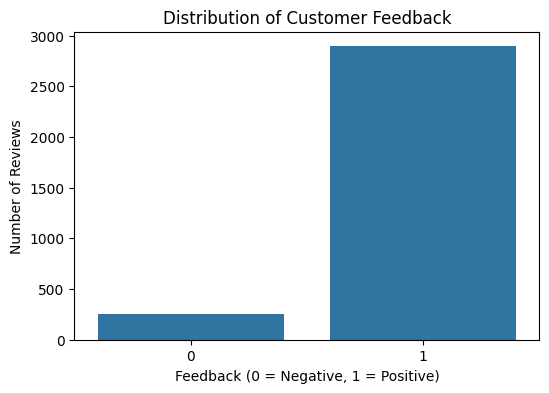

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='feedback')

plt.title('Distribution of Customer Feedback')
plt.xlabel('Feedback (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')

plt.show()

Visualize the relationship between variations and ratings

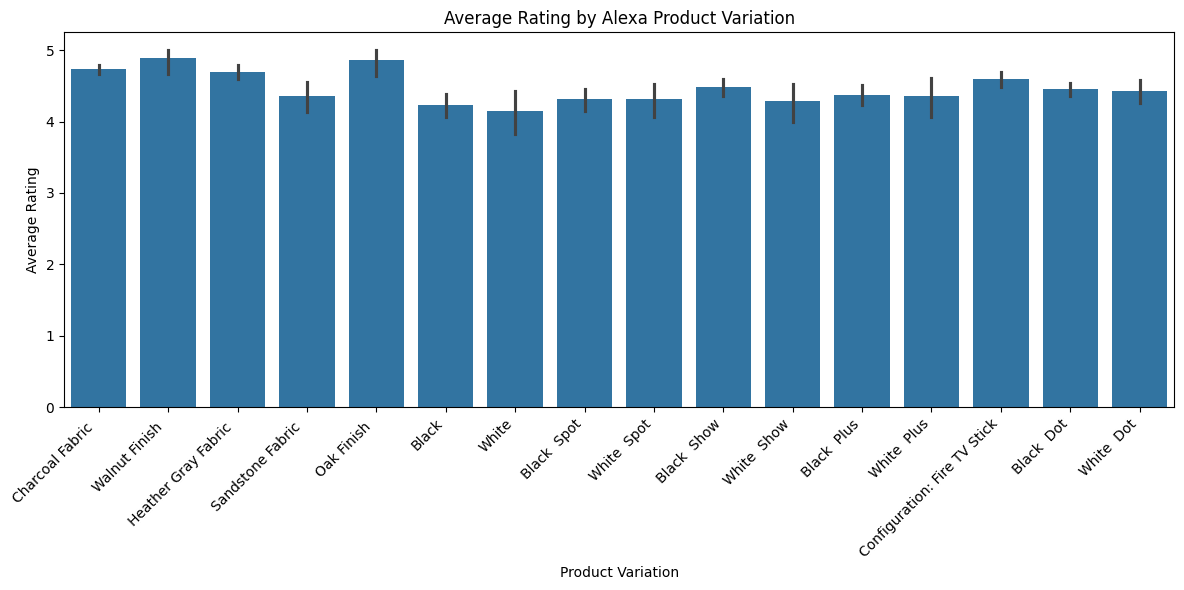

In [9]:
# Visualize the relationship between variations and ratings

plt.figure(figsize=(12, 6))

sns.barplot(data=df,x='variation',y='rating')

plt.title('Average Rating by Alexa Product Variation')
plt.xlabel('Product Variation')
plt.ylabel('Average Rating')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Drop irrelevant columns

In [10]:
#Drop irrelevant columns

df = df.drop(['date', 'rating'], axis=1)

df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


One-Hot Encoding

In [11]:
# Perform one-hot encoding on the 'variation' column

variation_encoded = pd.get_dummies(df['variation'],prefix='variation')
variation_encoded.head()

,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [12]:
df_encoded = pd.concat([df.drop('variation', axis=1), variation_encoded],axis=1)

df_encoded.head()

,verified_reviews,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,Love my Echo!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


Tokenize the reviews

In [13]:
# Tokenize the 'verified_reviews' column

# First replace missing reviews with empty strings
df_encoded['verified_reviews'] = df_encoded['verified_reviews'].fillna('')

vectorizer = CountVectorizer()

review_vectors = vectorizer.fit_transform(df_encoded['verified_reviews'])

print("Number of reviews:", review_vectors.shape[0])
print("Number of text features:", review_vectors.shape[1])

Number of reviews: 3150
Number of text features: 4044


In [15]:
# Combine tokenized reviews with the main dataframe

review_features = pd.DataFrame(
    review_vectors.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_encoded.index)

# Removing the original text column
df_model = df_encoded.drop('verified_reviews', axis=1)

# Combine text features and variation features
df_model = pd.concat([df_model, review_features],axis=1)

print("Final modeling dataset shape:", df_model.shape)

df_model.head()

Final modeling dataset shape: (3150, 4061)


,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0


Prepare data for modeling

In [20]:
# Split the data into features (X) and target (y)

# Removing any duplicate column names
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

X = df_model.drop('feedback', axis=1)
y = df_model['feedback']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeedback distribution:")
print(y.value_counts())

X shape: (3150, 4059)
y shape: (3150,)

Feedback distribution:
feedback
1    2893
0     257
Name: count, dtype: int64


Split the data into features (X) and target (y)

In [21]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2520
Testing samples: 630


Train the Random Forest model

In [22]:
# Define and train a Random Forest Classifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Evaluate the model

In [23]:
# Generate predictions and evaluate the model's performance

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [24]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 10  41]
 [  2 577]]


Plot confusion matrix

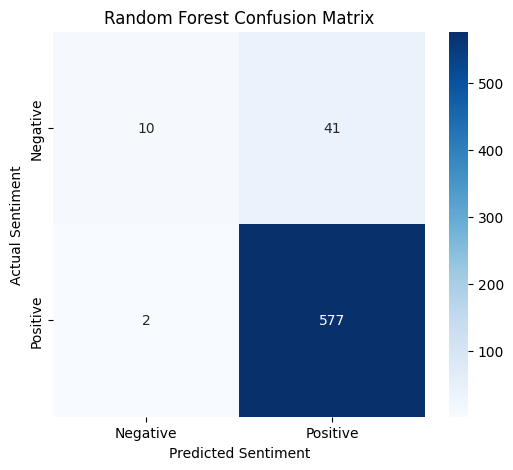

In [25]:
# plot of confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'])

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

Classification report

In [28]:
# Print classification report

print("____________________Classification Report:____________________")
print(
    classification_report(y_test,y_pred,target_names=['Negative', 'Positive']))

____________________Classification Report:____________________
              precision    recall  f1-score   support

    Negative       0.83      0.20      0.32        51
    Positive       0.93      1.00      0.96       579

    accuracy                           0.93       630
   macro avg       0.88      0.60      0.64       630
weighted avg       0.93      0.93      0.91       630



Feature Importance

In [29]:
# TODO: Visualize feature importance

# fetch feature importance from the trained Random Forest model
feature_importance = rf_model.feature_importances_

# Creating DF with feature names and their importance
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': feature_importance})

# Sort by importance and choose top 15
top_features = importance_df.sort_values(by='Importance',ascending=False).head(15)

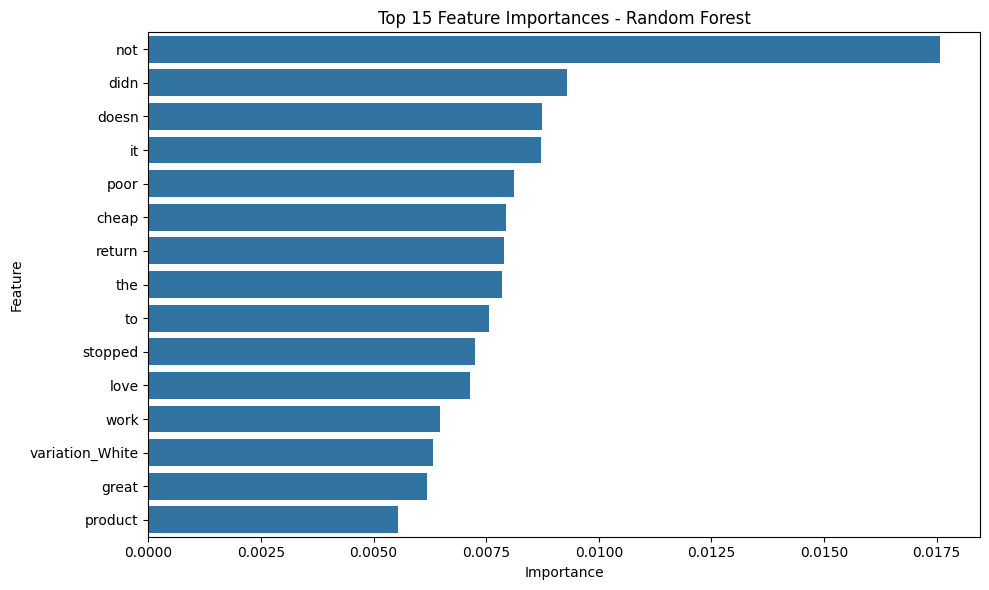

In [30]:
# Plot the top 15 features
plt.figure(figsize=(10, 6))

sns.barplot(data=top_features,x='Importance',y='Feature')

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

Make predictions on new data

In [34]:
def predict_sentiment(new_review):

    # Convert the new review into the same numerical format
    review_vector = vectorizer.transform([new_review])

    # Convert the vector into a DataFrame
    new_review_df = pd.DataFrame(
        review_vector.toarray(),
        columns=vectorizer.get_feature_names_out())

    # Add the variation columns used by the model
    for column in variation_encoded.columns:
        new_review_df[column] = 0

    # Make sure the columns match the training data
    new_review_df = new_review_df.reindex(columns=X.columns,fill_value=0)

    # Predict sentiment
    prediction = rf_model.predict(new_review_df)[0]

    # Convert 1/0 into Positive/Negative
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

Example usage of your prediction function:

In [35]:
# Example usage of your prediction function

new_review = "I love my Alexa device! It's so helpful."

predicted_sentiment = predict_sentiment(new_review)

print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive


In [36]:
# Analyzing Model Performance

train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

difference = train_accuracy - test_accuracy

print(f"Accuracy Difference: {difference:.4f}")

if difference > 0.10:
    print("The model may be overfitting because training accuracy is considerably higher than testing accuracy.")
elif train_accuracy < 0.70 and test_accuracy < 0.70:
    print("The model may be underfitting because both training and testing accuracy are relatively low.")
else:
    print("The model shows reasonably consistent performance between training and testing data.")

Training Accuracy: 0.9952
Testing Accuracy: 0.9317
Accuracy Difference: 0.0635
The model shows reasonably consistent performance between training and testing data.


**Summary of Findings:**

The Random Forest model overall performed well, achieving 0.93 testing accuracy. The model signficantly classified positive reviews compared to negative reviews. In conclusion the model was effective at predicting customer sentiment.

Colab Link

https://colab.research.google.com/drive/1WZuewX_5gKRbrV548LzxD37FAcEytawm?usp=sharing